In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian import *

In [2]:
def neighbor_maps_square(lattice: SquareLattice):
    X, Y = lattice.X, lattice.Y
    N = lattice.num_sites

    nbr = {"+x": -cp.ones(N, dtype=int),
           "-x": -cp.ones(N, dtype=int),
           "+y": -cp.ones(N, dtype=int),
           "-y": -cp.ones(N, dtype=int)}

    for y in range(Y):
        for x in range(X):
            i = y * X + x
            # +x
            if x < X:
                nbr["+x"][i] = i + 1
            elif lattice.pbc_x and X > 2:
                nbr["+x"][i] = y * X

            # -x
            if x > 0:
                nbr["-x"][i] = i - 1
            elif lattice.pbc_x and X > 2:
                nbr["-x"][i] = y * X + (X-1)

            # +y
            if y < Y:
                nbr["+y"][i] = (y+1) * X + x
            elif lattice.pbc_y and Y > 2:
                nbr["+y"][i] = x

            # -y
            if y > 0:
                nbr["-y"][i] = (y-1) * X + x
            elif lattice.pbc_y and Y > 2:
                nbr["-y"][i] = (Y-1) * X + x

    return nbr


In [3]:
def gather_at(j_idx, arr):
    # arr is (Neig,N). Return (Neig,N) with invalid neighbors zeroed.
    valid = (j_idx >= 0)
    j_safe = cp.where(valid, j_idx, 0)
    out = arr[:, j_safe]
    return out * valid[cp.newaxis, :]  # zero invalid sites

def correlators(H, T):

    nbr = neighbor_maps_square(H.lattice)
    F0 = cp.zeros_like(H.gap)
    F = {}          # singlet-like (up at i, down at j)
    Fuu = {}        # triplet component uu
    Fdd = {}        # triplet component dd


    eigval, eigvec = H.diagonalize(drop_matrix=False)
    eigvec = eigvec[:, eigval >= 0]
    eigval = eigval[eigval >= 0]
    eigvec = eigvec.T.reshape((eigval.size, -1, 4))

    f = fermi_dirac(eigval, T)          # (Neig,)
    u_up = eigvec[:, :, 0]              # (Neig, Nsites)
    u_dn = eigvec[:, :, 1]
    v_up = eigvec[:, :, 2]
    v_dn = eigvec[:, :, 3]

    F0 = (
        cp.einsum('ni,ni,n->i', u_dn, cp.conj(v_up), f) +
        cp.einsum('ni,ni,n->i', u_up, cp.conj(v_dn), (1-f))
    )
    
    for d in ["+x", "-x", "+y", "-y"]:
        j = nbr[d]

        vdn_j = gather_at(j, v_dn)
        udn_j = gather_at(j, u_dn)
        vup_j = gather_at(j, v_up)
        uup_j = gather_at(j, u_up)

        # Eqn 1: F_{i,↑↓}^d
        F[d] = (
            cp.einsum('ni,ni,n->i', u_up, cp.conj(vdn_j), (1 - f)) +
            cp.einsum('ni,ni,n->i', v_up, cp.conj(udn_j), f)
        )
        # Eqn 2: F_{i,↑↑}^d
        Fuu[d] = (
            cp.einsum('ni,ni,n->i', u_up, cp.conj(vup_j), (1 - f)) +
            cp.einsum('ni,ni,n->i', v_up, cp.conj(uup_j), f)
        )
        # Eqn 3: F_{i,↓↓}^d
        Fdd[d] = (
            cp.einsum('ni,ni,n->i', u_dn, cp.conj(vdn_j), (1 - f)) +
            cp.einsum('ni,ni,n->i', v_dn, cp.conj(udn_j), f)
        )
    return F0, F, Fuu, Fdd

In [4]:
def correlators(H, T):
    N = H.lattice.num_sites
    F0 = cp.zeros_like(H.gap)
    F = cp.zeros((N,N), dtype=cp.complex128)
    Fuu = cp.zeros((N,N), dtype=cp.complex128)
    Fdd = cp.zeros((N,N), dtype=cp.complex128)

    eigval, eigvec = H.diagonalize(drop_matrix=False)
    eigvec = eigvec[:, eigval >= 0]
    eigval = eigval[eigval >= 0]
    eigvec = eigvec.T.reshape((eigval.size, -1, 4))

    f = fermi_dirac(eigval, T)          # (Neig,)
    u_up = eigvec[:, :, 0]              # (Neig, Nsites)
    u_dn = eigvec[:, :, 1]
    v_up = eigvec[:, :, 2]
    v_dn = eigvec[:, :, 3]

    F0 = (
        cp.einsum('ni,ni,n->i', u_dn, cp.conj(v_up), f) +
        cp.einsum('ni,ni,n->i', u_up, cp.conj(v_dn), (1-f))
    )
    
    for i,j in H.lattice.edges:

        # Eqn 1: F_{ij,↑↓}^d
        F[i][j] = (
            cp.einsum('n,n,n->', u_up[:,i], cp.conj(v_dn[:,j]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_up[:,i]), u_dn[:,j], f)
        )        
        # Eqn 1: F_{ji,↑↓}^d
        F[j][i] = (
            cp.einsum('n,n,n->', u_up[:,j], cp.conj(v_dn[:,i]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_up[:,j]), u_dn[:,i], f)
        )
        # Eqn 2: F_{ij,↑↑}^d
        Fuu[i][j] = (
            cp.einsum('n,n,n->', u_up[:,i], cp.conj(v_up[:,j]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_up[:,i]), u_up[:,j], f)
        )
        # Eqn 2: F_{ji,↑↑}^d
        Fuu[j][i] = (
            cp.einsum('n,n,n->', u_up[:,j], cp.conj(v_up[:,i]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_up[:,j]), u_up[:,i], f)
        )
        # Eqn 3: F_{ij,↓↓}^d
        Fdd[i][j] = (
            cp.einsum('n,n,n->', u_dn[:,i], cp.conj(v_dn[:,j]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_dn[:,j]), u_dn[:,i], f)
        )
        # Eqn 3: F_{ji,↓↓}^d
        Fdd[j][i] = (
            cp.einsum('n,n,n->', u_dn[:,j], cp.conj(v_dn[:,i]), (1 - f)) +
            cp.einsum('n,n,n->', cp.conj(v_dn[:,i]), u_dn[:,j], f)
        )
    return F0, F, Fuu, Fdd

In [5]:
def arr_converged(new, old, atol, rtol):
    return (
        cp.all(
            cp.max(cp.abs(new - old)) < atol + rtol * cp.max(cp.abs(new))
        )
    )

In [6]:
def bdg_self_consistency(H, U, V, V_prime, 
                         T, max_iter=100,
                         atol=1e-6, rtol=1e-4,
                         with_corr = False):
        flag = False
        num_sites = H.lattice.num_sites
        F0 = cp.zeros_like(H.gap)
        F = cp.zeros((num_sites,num_sites), dtype=cp.complex128)
        Fuu = cp.zeros((num_sites,num_sites), dtype=cp.complex128)
        Fdd = cp.zeros((num_sites,num_sites), dtype=cp.complex128)
        for iteration in range(max_iter):
            F0_new, F_new, Fuu_new, Fdd_new = correlators(H, T)
            gap_0 = -U * F0_new

            for i in range(num_sites):
                # indices for the 4x4 block of site i
                sl = slice(4*i, 4*(i+1))
                H.matrix[sl, sl][:2, 2:] = -1j * gap_0[i] * s2
                H.matrix[sl, sl][2:, :2] = (-1j * gap_0[i] * s2).conj().T

            for i, j in H.lattice.edges:
                sli = slice(4*i, 4*(i+1))
                slj = slice(4*j, 4*(j+1))

                H.matrix[sli, slj][0,3] = V * F_new[i][j]
                H.matrix[sli, slj][1,2] = V * F_new[i][j]
                H.matrix[sli, slj][2,1] = (V * F_new[j][i]).conj().T
                H.matrix[sli, slj][3,0] = (V * F_new[j][i]).conj().T

                H.matrix[slj, sli][0,2] = V_prime * Fuu_new[i][j]
                H.matrix[slj, sli][1,3] = V_prime * Fdd_new[i][j]
                H.matrix[slj, sli][2,0] = (V_prime * Fuu_new[j][i]).conj().T
                H.matrix[slj, sli][3,1] = (V_prime * Fdd_new[j][i]).conj().T

            if (cp.max(cp.abs(F0_new - F0)) < atol + rtol * cp.max(cp.abs(gap_0))
                and arr_converged(F_new, F, atol, rtol)
                and arr_converged(Fuu_new, Fuu, atol, rtol)
                and arr_converged(Fdd_new, Fdd, atol, rtol)
                ):
                print(f"Converged after {iteration+1} iterations.")
                flag = True
                F0 = F0_new
                F = F_new   
                Fuu = Fuu_new
                Fdd = Fdd_new
                break
            F0 = F0_new
            F = F_new
            Fuu = Fuu_new
            Fdd = Fdd_new
            
        if not flag:
            print(f"Failed to converge after {iteration+1} iterations")
        if with_corr:
            return F0, F, Fuu, Fdd

In [7]:
# def bdg_self_consistency(H, U, V, V_prime, 
#                          T, max_iter=100,
#                          atol=1e-6, rtol=1e-4,
#                          with_corr = False):
#         flag = False
#         num_sites = H.lattice.num_sites
#         F0 = cp.ones(num_sites, dtype=cp.complex128) * 0.1
#         F = {d: cp.ones(num_sites, dtype=cp.complex128) * 0.1 for d in ["+x", "-x", "+y", "-y"]}
#         Fuu = {d: cp.ones(num_sites, dtype=cp.complex128) * 0.1 for d in ["+x", "-x", "+y", "-y"]}
#         Fdd = {d: cp.ones(num_sites, dtype=cp.complex128) * 0.1 for d in ["+x", "-x", "+y", "-y"]}

#         for iteration in range(max_iter):
#             F0_new, F_new, Fuu_new, Fdd_new = correlators(H, T)
#             gap_0 = -U * F0_new

#             for i in range(num_sites):
#                 # indices for the 4x4 block of site i
#                 sl = slice(4*i, 4*(i+1))
#                 H.matrix[sl, sl][:2, 2:] = -1j * gap_0[i] * s2
#                 H.matrix[sl, sl][2:, :2] = (-1j * gap_0[i] * s2).conj().T

#             for i, j in H.lattice.edges:
#                 # F_xT = (F["+x"][i]-F["-x"][j])/2
#                 # F_yT = (F["+y"][i]-F["-y"][j])/2
#                 sli = slice(4*i, 4*(i+1))
#                 slj = slice(4*j, 4*(j+1))
#                 dir = H.lattice.get_dir(i, j)

#                 H.matrix[sli, slj][0,3] = V * F_new[dir][i]
#                 H.matrix[sli, slj][1,2] = V * F_new[dir][i]
#                 H.matrix[sli, slj][2,1] = (V * F_new[dir][i]).conj().T
#                 H.matrix[sli, slj][3,0] = (V * F_new[dir][i]).conj().T

#                 H.matrix[slj, sli][0,2] = V_prime * Fuu_new[dir][i]
#                 H.matrix[slj, sli][1,3] = V_prime * Fdd_new[dir][i]
#                 H.matrix[slj, sli][2,0] = (V_prime * Fuu_new[dir][i]).conj().T
#                 H.matrix[slj, sli][3,1] = (V_prime * Fdd_new[dir][i]).conj().T

#             if (cp.max(cp.abs(F0_new - F0)) < atol + rtol * cp.max(cp.abs(gap_0))
#                 and dict_converged(F_new, F, atol, rtol)
#                 and dict_converged(Fuu_new, Fuu, atol, rtol)
#                 and dict_converged(Fdd_new, Fdd, atol, rtol)
#                 ):
#                 print(f"Converged after {iteration+1} iterations.")
#                 flag = True
#                 F0 = F0_new
#                 F = F_new   
#                 Fuu = Fuu_new
#                 Fdd = Fdd_new
#                 break
#             F0 = F0_new
#             F = F_new
#             Fuu = Fuu_new
#             Fdd = Fdd_new
            
#         if not flag:
#             print(f"Failed to converge after {iteration+1} iterations")
#         if with_corr:
#             return F0, F, Fuu, Fdd

In [30]:
t = 1
mu = -1* t
gap_0 = 0.0
gap_p= cp.array([0.0, 0.1j]) * t
gap_d = 0.1 *  t
X,Y = 30,30
U = 2 * t
V = 2 * t
lattice = Lattice(X, Y, pbc_x=False, pbc_y=False)
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_0 * s2
    block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)
    # H.set_gap(gap_0,i)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j), gap_p=gap_p, gap_d=gap_d)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i), gap_p=gap_p, gap_d=gap_d)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)
# H.gap_s = cp.ones(lattice.num_sites, dtype=cp.complex128) * 0.1


In [31]:
print(cp.allclose(H.matrix, H.matrix.conj().T, rtol=1e-6, atol=1e-6))

True


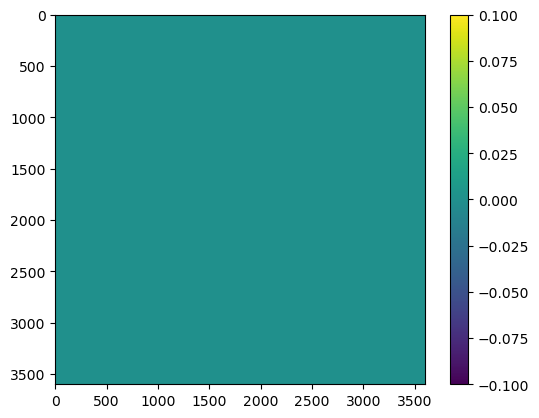

In [32]:
check_mat = H.matrix - H.matrix.conj().T

plt.imshow(np.abs(cp.asnumpy(check_mat)))
plt.colorbar()

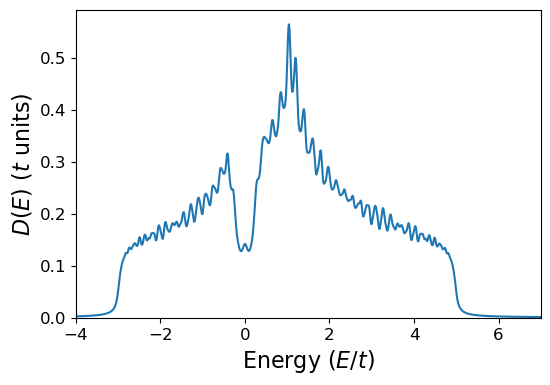

In [33]:
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.05, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [42]:
# %prun bdg_self_consistency(H,U=U,V=V,V_prime=V,T=0,atol=1e-2,rtol=1e-2, max_iter=100, with_corr=True)

Converged after 19 iterations.


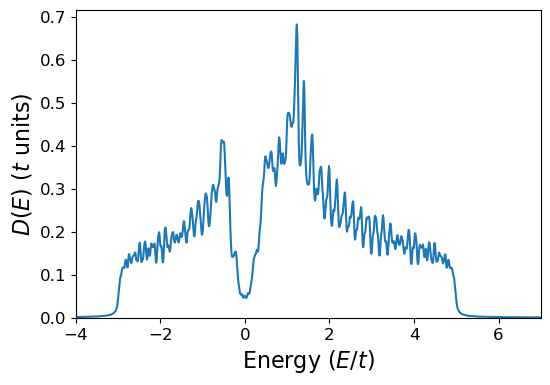

In [34]:
F0, F, Fuu, Fdd = bdg_self_consistency(H,U=U,V=V,V_prime=0,T=0,atol=1e-4,rtol=1e-3, max_iter=50, with_corr=True)

energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.03, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [31]:
print(cp.allclose(H.matrix, H.matrix.conj().T, rtol=1e-4, atol=1e-4))

True


In [12]:
test_lattice = Lattice(10,10)
for i, j in test_lattice.edges:
    print(i, j, test_lattice.get_disp(i,j))

print(test_lattice.get_dir(0,10))

0 1 [1 0]
0 10 [ 0 -1]
1 2 [1 0]
1 0 [-1  0]
1 11 [ 0 -1]
2 3 [1 0]
2 1 [-1  0]
2 12 [ 0 -1]
3 4 [1 0]
3 2 [-1  0]
3 13 [ 0 -1]
4 5 [1 0]
4 3 [-1  0]
4 14 [ 0 -1]
5 6 [1 0]
5 4 [-1  0]
5 15 [ 0 -1]
6 7 [1 0]
6 5 [-1  0]
6 16 [ 0 -1]
7 8 [1 0]
7 6 [-1  0]
7 17 [ 0 -1]
8 9 [1 0]
8 7 [-1  0]
8 18 [ 0 -1]
9 8 [-1  0]
9 19 [ 0 -1]
10 11 [1 0]
10 20 [ 0 -1]
10 0 [0 1]
11 12 [1 0]
11 10 [-1  0]
11 21 [ 0 -1]
11 1 [0 1]
12 13 [1 0]
12 11 [-1  0]
12 22 [ 0 -1]
12 2 [0 1]
13 14 [1 0]
13 12 [-1  0]
13 23 [ 0 -1]
13 3 [0 1]
14 15 [1 0]
14 13 [-1  0]
14 24 [ 0 -1]
14 4 [0 1]
15 16 [1 0]
15 14 [-1  0]
15 25 [ 0 -1]
15 5 [0 1]
16 17 [1 0]
16 15 [-1  0]
16 26 [ 0 -1]
16 6 [0 1]
17 18 [1 0]
17 16 [-1  0]
17 27 [ 0 -1]
17 7 [0 1]
18 19 [1 0]
18 17 [-1  0]
18 28 [ 0 -1]
18 8 [0 1]
19 18 [-1  0]
19 29 [ 0 -1]
19 9 [0 1]
20 21 [1 0]
20 30 [ 0 -1]
20 10 [0 1]
21 22 [1 0]
21 20 [-1  0]
21 31 [ 0 -1]
21 11 [0 1]
22 23 [1 0]
22 21 [-1  0]
22 32 [ 0 -1]
22 12 [0 1]
23 24 [1 0]
23 22 [-1  0]
23 33 [ 0 -1]
23 13 

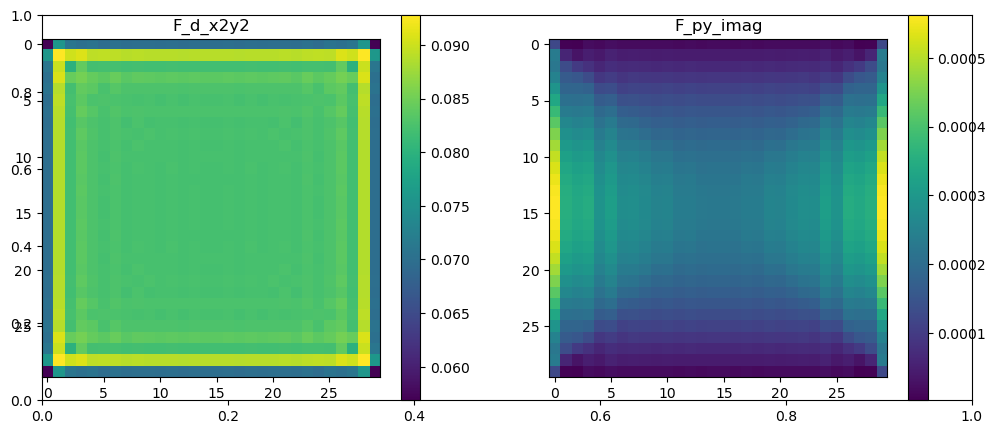

In [48]:
F_S = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_T = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

F_xplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_xminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

for i,j in H.lattice.edges:
        F_S[i] += (F[i][j]+F[j][i])/2
        F_T[i] += (F[i][j]-F[j][i])/2
        dir = H.lattice.get_dir(i,j)
        if dir == "+x":
            F_xplus[i] += F[i][j]
            # F_xminus.append(F[j][i].get())
        elif dir == "-x":
            F_xminus[i] += F[i][j]
            # F_xplus.append(F[j][i].get())
        elif dir == "+y":
            F_yplus[i] += F[i][j]
            # F_yminus.append(F[j][i].get())
        elif dir == "-y":
            F_yminus[i] += F[i][j]
            # F_yplus.append(F[j][i].get())
    
# plt.imshow(np.abs(cp.asnumpy(F)))
# plt.plot(cp.asnumpy((F0)), label="F0")
# plt.plot(cp.asnumpy((F_xplus+F_xminus)/4), label="F_s x-bond")
# plt.imshow(np.abs(cp.asnumpy((F_xplus-F_xminus)/2)).reshape(30,30), label="F_t x-bond")
# plt.imshow(np.abs(cp.asnumpy((F_yplus-F_yminus)/2)).reshape(30,30), label="F_t y-bond")
# plt.imshow(np.abs(cp.asnumpy((F_S)).reshape(30,30)), label="F_S")
plt.subplots(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(np.abs(np.real(cp.asnumpy((F_xplus+F_xminus-F_yplus-F_yminus)/4).reshape(30,30))), label="F_T_real")
plt.title("F_d_x2y2")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(np.abs(np.imag(cp.asnumpy((F_yplus-F_yminus)/2).reshape(30,30))), label="F_T_imag")
plt.title("F_py_imag")
plt.colorbar()

plt.show()